In [1]:
#import all necessary libraries for this analysis on collision
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import re


In [2]:
# import the spreadsheet from my laptop
df1 = pd.read_csv('/Users/seuncaleb/Downloads/dft-road-casualty-statistics-vehicle-2024.csv',
                low_memory=False)


In [3]:
#import code book
code_book = pd.read_csv('/Users/seuncaleb/Downloads/code_book  - 2024_code_list.csv', low_memory=False)

In [4]:
#drop index of variables you do not want to decode
code_book.drop([1623, 1652, 1624],  inplace=True)

In [5]:
#import the code book to decode the variable and save it to dictionary as value key pairs
code_book['code'] = code_book['code'].astype(str)

mapping_collection = {}

for code, label in code_book.groupby('Variable_name'):
    mapping_dictionary = label.set_index('code')['label'].to_dict()
    mapping_collection[code] = mapping_dictionary


In [6]:
 #create a new variable to hold useful columns and drop columns not in use

new_data = df1.drop(['collision_index', 'collision_ref_no', 'vehicle_reference', 'towing_and_articulation','vehicle_manoeuvre_historic','vehicle_location_restricted_lane_historic', 'skidding_and_overturning', 'journey_purpose_of_driver_historic', 'engine_capacity_cc', 'propulsion_code', 'driver_imd_decile', 'lsoa_of_driver', 'driver_distance_banding', 'journey_purpose_of_driver_historic', 'vehicle_left_hand_drive', 'generic_make_model', 'escooter_flag', 'collision_year' ], axis=1)

In [7]:
#using the coded file, decode the categories that are being used for the new data set created
columns_to_decode = new_data.columns

for col in columns_to_decode:
    if col in mapping_collection:
        mapping_dic =mapping_collection[col]
        new_data[col] = new_data[col].astype(str).str.strip()
        new_data[col] = new_data[col].map(mapping_dic)

In [8]:
#replace null values for carriageway and use the mean for ages not provided

new_data['hit_object_in_carriageway']= new_data['hit_object_in_carriageway'].fillna("none")
new_data['hit_object_off_carriageway']= new_data['hit_object_off_carriageway'].fillna("none")
new_data['age_of_driver'] = np.where(new_data['age_of_driver'] == -1, new_data['age_of_driver'].mean(), new_data['age_of_driver'])

In [9]:
#in order to get accurate plotting, we would be filtering out rows that have uninformative data, so as to make our plotting and analysis more accurate
for_missing = 'Missing'
missing_labels = ['Data missing or out of range', 'Not known', 'Not applicable', 'Unknown', 'none', 'unknown (self reported)', 'Missing', 'Unknown vehicle type (self rep only)', np.nan]
new_data_filtered = new_data[
    ~new_data['vehicle_type'].isin(missing_labels) &
    ~new_data['vehicle_manoeuvre'].isin(missing_labels) &
    ~new_data['junction_location'].isin(missing_labels) &
    ~new_data['sex_of_driver'].isin(missing_labels) &
    ~new_data['age_band_of_driver'].isin(missing_labels) &
    ~new_data['first_point_of_impact'].isin(missing_labels) &
    new_data['age_of_driver'].notna()
].copy()

**Situational Dynamics & Driver Gender**

In [10]:
# set a variable for your the manoeuvre and the location of the vehicle
manoeuvre_by_junction = new_data_filtered.groupby(['junction_location', 'vehicle_manoeuvre']).size().unstack(fill_value=0)

# Normalize by row
manoeuvre_proportion = manoeuvre_by_junction.div(manoeuvre_by_junction.sum(axis=1), axis=0)

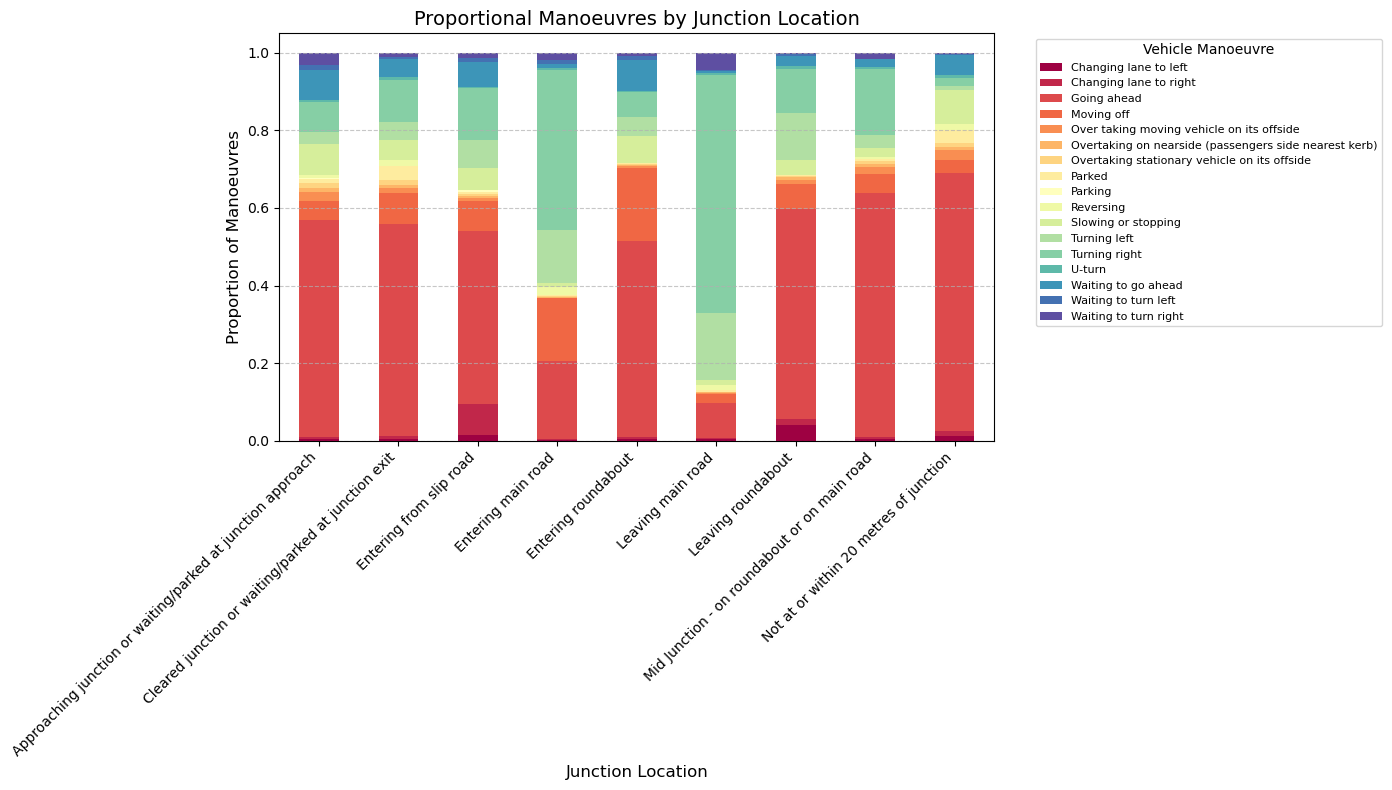

In [11]:
#this is for the first chart.  this shows the proportion of manoeuvres by the location of the junction
plt.figure(figsize=(14, 8))
manoeuvre_proportion.plot(kind='bar', stacked=True, colormap='Spectral', ax=plt.gca())
plt.title('Proportional Manoeuvres by Junction Location', fontsize=14)
plt.xlabel('Junction Location', fontsize=12)
plt.ylabel('Proportion of Manoeuvres', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vehicle Manoeuvre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

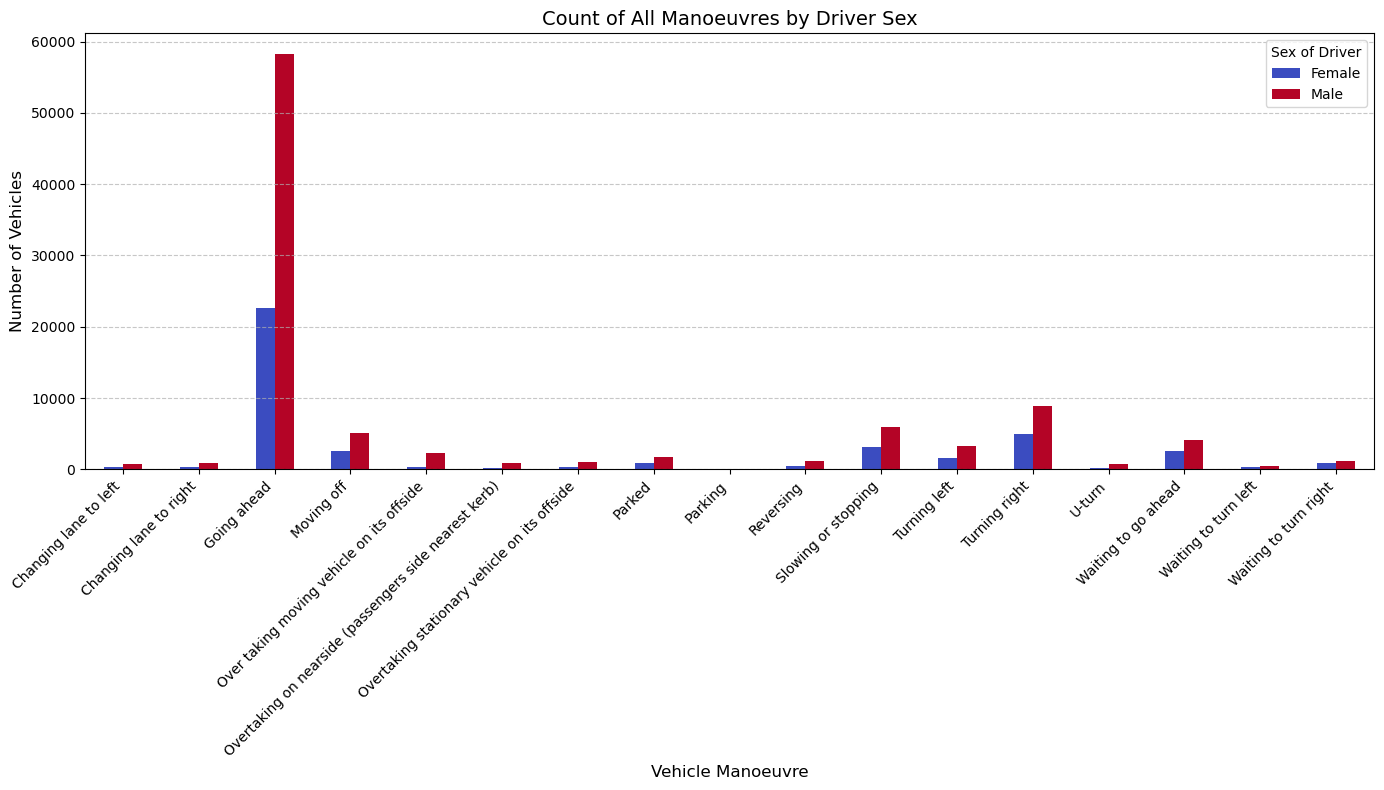

In [12]:
# this is for the second chart, Manoeuvre Count by Driver Sex (Grouped Bar Chart)
manoeuvre_by_sex = new_data_filtered.groupby(['vehicle_manoeuvre', 'sex_of_driver']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
manoeuvre_by_sex.plot(kind='bar', colormap='coolwarm', ax=plt.gca())
plt.title('Count of All Manoeuvres by Driver Sex', fontsize=14)
plt.xlabel('Vehicle Manoeuvre', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex of Driver')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Drivers' age and Collision**

In [13]:
#the distribution of age across all vehicle types
vehicles = new_data_filtered['vehicle_type'].unique().tolist()
age_data = [new_data_filtered[new_data_filtered['vehicle_type'] == v]['age_of_driver'].values for v in vehicles]

/var/folders/0l/2z5cg_jx6gv6bfst58k8tsdm0000gn/T/ipykernel_91188/4152885899.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


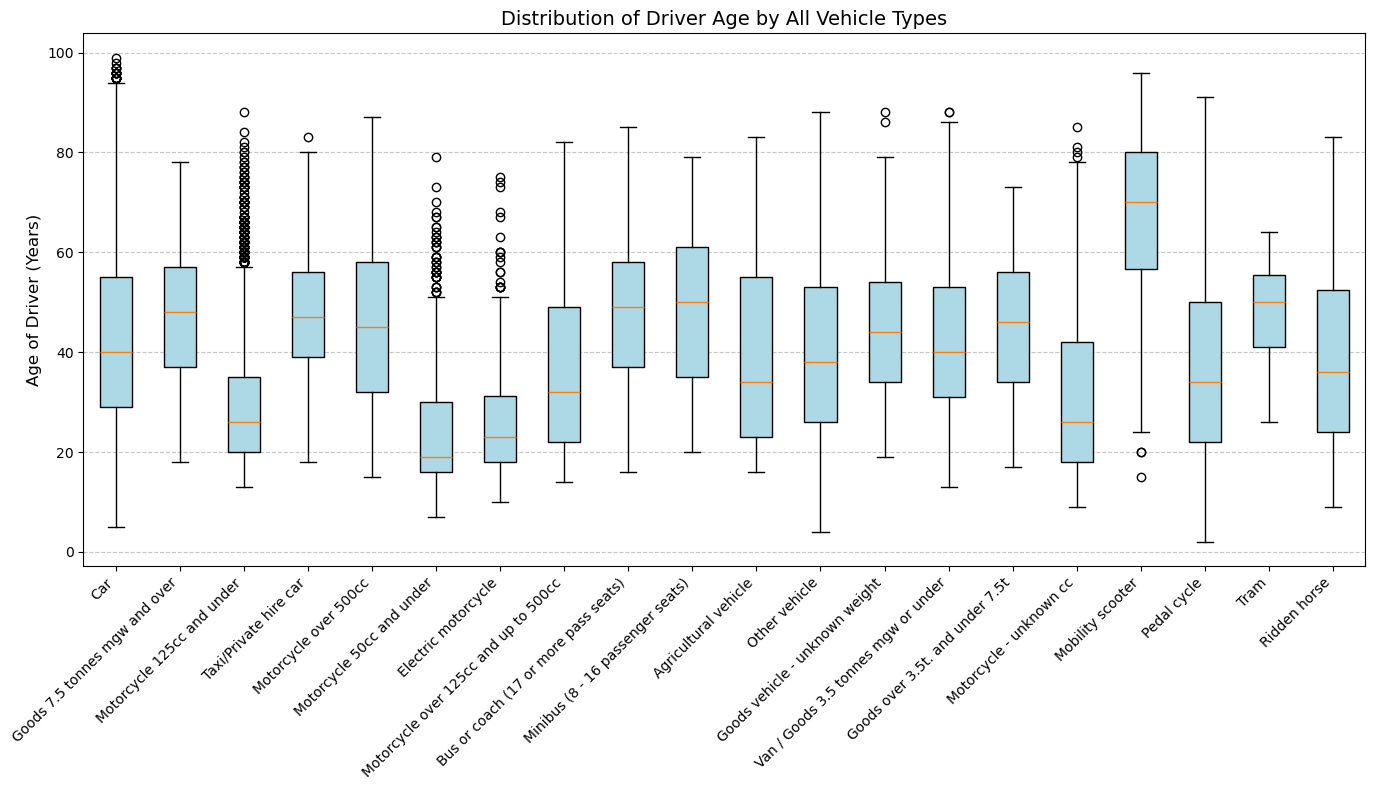

In [14]:
#this is for the third chart
plt.figure(figsize=(14, 8))
plt.boxplot(
    age_data,
    labels=vehicles,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
plt.title('Distribution of Driver Age by All Vehicle Types', fontsize=14)
plt.ylabel('Age of Driver (Years)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
impact_by_age_band = new_data_filtered.groupby(['age_band_of_driver', 'first_point_of_impact']).size().unstack(fill_value=0)

# Define the ordinal order for age bands (for correct plotting order)
age_band_order = ['0 - 5', '6 - 10', '11 - 15', '16 - 20', '21 - 25', '26 - 35', '36 - 45', '46 - 55', '56 - 65', '66 - 75', 'Over 75']
impact_by_age_band = impact_by_age_band.reindex(age_band_order, axis=0).dropna(how='all')

# Normalize by row (Age Band)
impact_proportion_age = impact_by_age_band.div(impact_by_age_band.sum(axis=1), axis=0)

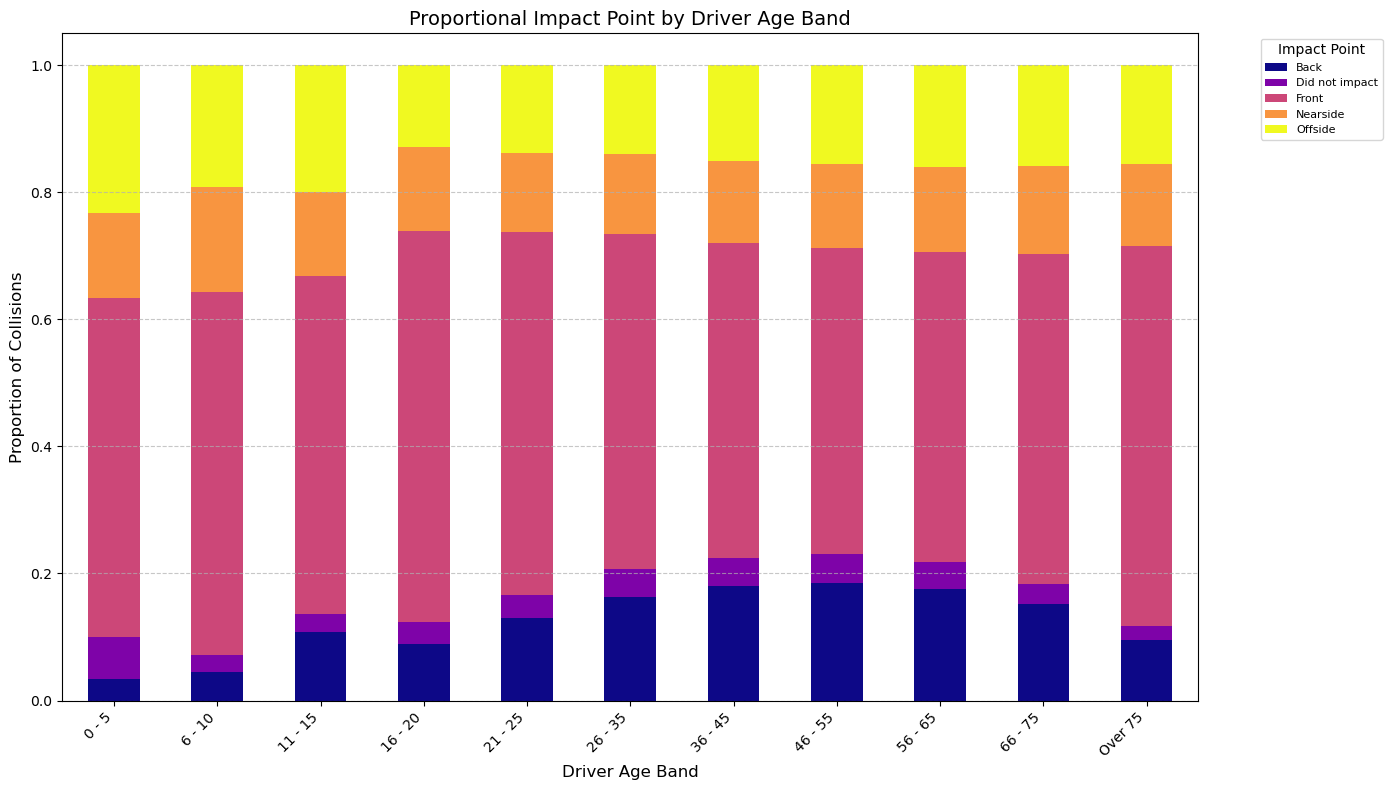

In [16]:
#this is for the fourth chart
plt.figure(figsize=(14, 8))
impact_proportion_age.plot(kind='bar', stacked=True, colormap='plasma', ax=plt.gca())
plt.title('Proportional Impact Point by Driver Age Band', fontsize=14)
plt.xlabel('Driver Age Band', fontsize=12)
plt.ylabel('Proportion of Collisions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Impact Point', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Preparing Data for supervised and Unsupervised learning**

*K-MEANS*

In [17]:
# Define the numerical and categorical columns from the new_data structure
numerical_columns = ['age_of_driver', 'age_of_vehicle']
categorical_columns = [
    'vehicle_type', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to',
    'vehicle_location_restricted_lane', 'junction_location', 'hit_object_in_carriageway',
    'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact',
    'journey_purpose_of_driver', 'sex_of_driver', 'age_band_of_driver'
]

In [18]:
# Create the final feature set
feature_data = new_data[numerical_columns + categorical_columns].copy()

In [19]:
for col in categorical_columns:
    feature_data[col] = feature_data[col].replace(missing_labels, for_missing)
    feature_data[col] = feature_data[col].fillna(for_missing)

for col in categorical_columns:
    valid_rows= feature_data[col] != for_missing
    feature_data = feature_data[valid_rows].copy()

feature_data.dropna(inplace=True)

In [20]:
print(f"Total samples prepared for encoding: {len(feature_data)}")
print(f"Features ready for encoding: {numerical_columns + categorical_columns}")

Total samples prepared for encoding: 1727
Features ready for encoding: ['age_of_driver', 'age_of_vehicle', 'vehicle_type', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'junction_location', 'hit_object_in_carriageway', 'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact', 'journey_purpose_of_driver', 'sex_of_driver', 'age_band_of_driver']


In [21]:
# Identify which columns are still categorical
categorical_features_to_encode = feature_data.select_dtypes(include='object').columns.tolist()

In [22]:
#One-Hot Encoding
encoded_features = pd.get_dummies(feature_data, columns=categorical_features_to_encode, drop_first=True)

In [23]:
#Remove redundant age band column to avoid multicollinearity
if 'age_band_of_driver' in encoded_features.columns:
    encoded_features.drop(columns=['age_band_of_driver_Missing'], inplace=True, errors='ignore')

In [24]:
sample_size = 10000
x_sample = encoded_features.sample(n=min(sample_size, len(encoded_features)), random_state=42)

print(f"Features before encoding: {len(feature_data.columns)}")
print(f"Features after encoding : {len(encoded_features.columns)}")
print(f"Sample size used for clustering: {len(x_sample)}")

Features before encoding: 15
Features after encoding : 109
Sample size used for clustering: 1727


In [25]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_sample)

**Start K-Means Clustering**

In [26]:
# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(x_scaled)

In [27]:
# Create DataFrame for analysis (using scaled features and attaching labels)
cluster_analysis = pd.DataFrame(x_scaled, columns=x_sample.columns, index=x_sample.index)
cluster_analysis['Cluster'] = cluster_labels
cluster_summary = cluster_analysis.groupby('Cluster').mean().round(3).transpose()

In [28]:
# Clean feature names for readability
def clean_name(name):
    name = re.sub(r'^[a-z_]+_', '', name)
    name = re.sub(r'age_of_driver', 'Driver Age', name)
    name = re.sub(r'age_of_vehicle', 'Vehicle Age', name)
    return name

cluster_summary.index = cluster_summary.index.map(clean_name)
print(cluster_summary.to_markdown(index=True, numalign="left", stralign="left"))

|                                                               | 0      | 1      | 2      | 3      |
|:--------------------------------------------------------------|:-------|:-------|:-------|:-------|
| driver                                                        | 0.065  | -0.065 | 0.221  | -0.016 |
| vehicle                                                       | 0.01   | 0.014  | -0.07  | -0     |
| Bus or coach (17 or more pass seats)                          | 0.018  | -0.015 | 0.248  | -0.1   |
| Car                                                           | -0.01  | 0.018  | 0.038  | -0.048 |
| Electric motorcycle                                           | -0.042 | 0.015  | -0.042 | 0.015  |
| Goods 7.5 tonnes mgw and over                                 | 0.096  | -0.015 | -0.05  | -0.004 |
| Goods over 3.5t. and under 7.5t                               | -0.024 | -0.024 | -0.024 | 0.074  |
| Goods vehicle - unknown weight                                | -0.034 | -0.034 

*Decision Tree Classifier*

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
# Here we define what our target(x) would be and the features(y)
target_columns = 'first_point_of_impact'

#defining what x would be, that is the features that we need for this prediction
x = new_data.drop(columns=[target_columns], errors ='ignore')
y = new_data[target_columns]

In [31]:
#clear target and drop values that are not useful missing labels and for_missing variable will be useful here

valid_indices = y[~y.isin(missing_labels)].index

x = x.loc[valid_indices]
y = y.loc[valid_indices]

In [32]:
#drop all NAN/ NONE useful values in x
supervised_categorical_variable = x.select_dtypes(include = 'object').columns.tolist()

for col in supervised_categorical_variable:
    x[col] = x[col].replace(missing_labels, for_missing)
    x_col = ~x[col].isin(missing_labels)
    x = x[x_col].copy()
# Drop rows with any remaining NaNs in numerical columns (e.g., age_of_vehicle)
x.dropna(inplace=True)

In [33]:
# Realign y after dropping rows from X
y = y.loc[x.index]

# Encoding Categorical Data
x_encoded = pd.get_dummies(x, drop_first=True)

# Scaling Features
x_scaled = scaler.fit_transform(x_encoded)

# Convert back to DataFrame for splitting
x_scaled_df = pd.DataFrame(x_scaled, columns=x_encoded.columns, index=x_encoded.index)


In [34]:
# Data Split (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x_scaled_df, y,  test_size=0.2,  random_state=42, stratify=y )
print(f"Total Samples for Training (X_train): {x_train.shape[0]}")
print(f"Total Features (after encoding/scaling): {x_train.shape[1]}")

Total Samples for Training (X_train): 1381
Total Features (after encoding/scaling): 105


*Model training and eval*

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [36]:
# initialize and Train the Decision Tree Model Using a limited depth to prevent severe overfitting and keep it fast
training_data = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)
training_data.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [37]:
#Predict on the Test Set
y_predict = training_data.predict(x_test)

In [38]:
# evaluate Performance
accuracy = accuracy_score(y_test, y_predict)
target_names = y_test.unique()
report = classification_report(y_test, y_predict, target_names=target_names, zero_division=0)

print(report)

                precision    recall  f1-score   support

          Back       0.43      0.20      0.27        15
         Front       0.00      0.00      0.00         3
      Nearside       0.74      0.91      0.81       251
       Offside       0.09      0.02      0.04        42
Did not impact       0.06      0.03      0.04        35

      accuracy                           0.67       346
     macro avg       0.26      0.23      0.23       346
  weighted avg       0.57      0.67      0.61       346



In [39]:
# Extract Feature Importance
feature_importances = pd.Series(training_data.feature_importances_, index=x_train.columns)
top_10_features = feature_importances.nlargest(10)

#  Clean up feature names for printing
def clean_feature_name(name):
    name = re.sub(r'^[a-z_]+_', '', name)
    name = re.sub(r'age_of_driver', 'Driver Age', name)
    name = re.sub(r'age_of_vehicle', 'Vehicle Age', name)
    return name

#for the top ten features used in the prediction
top_10_features.index = top_10_features.index.map(clean_feature_name)

print("\n--- Final Classification Results  ---")
print(f"Test Accuracy: {accuracy:.4f}")
print("\n--- Top 10 Feature Importances for Impact Prediction ---")
print(top_10_features.to_string())
print("\n--- Detailed Classification Report ---")
print(report)


--- Final Classification Results  ---
Test Accuracy: 0.6734

--- Top 10 Feature Importances for Impact Prediction ---
vehicle                                 0.142922
driver                                  0.078461
West                                    0.046030
Reversing                               0.045629
Nearside and rebounded                  0.035647
Not known or not requested              0.034922
Wall or fence                           0.031843
Male                                    0.030713
Offside on to centrl res + rebounded    0.023316
Taxi/Private hire car                   0.023000

--- Detailed Classification Report ---
                precision    recall  f1-score   support

          Back       0.43      0.20      0.27        15
         Front       0.00      0.00      0.00         3
      Nearside       0.74      0.91      0.81       251
       Offside       0.09      0.02      0.04        42
Did not impact       0.06      0.03      0.04        35

      accurac